## Vectorization

In [225]:
from sklearn.feature_extraction.text import TfidfVectorizer
import csv

def load_text(filepath):
    texts, labels = [], []
    with open(filepath, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            texts.append(row['text'])
            labels.append(int(row['label']))
    return texts, labels

train_texts, train_labels = load_text('train_data.csv')
val_texts, val_labels = load_text('val_data.csv')
test_texts, test_labels = load_text('test_data.csv')

print("Train size:", len(train_texts), "Validation size:", len(val_texts), "Test size:", len(test_texts)) #sanity check



vectorizer = TfidfVectorizer(ngram_range=(1, 1), token_pattern=r"(?u)\b\w+\b|[!?]{1,}", min_df=2) 
''' include ? and ! as tokens as they should be relevant for subjectivity. Start with unigrams only for now. Will test bi and trigrams later. '''

x_train = vectorizer.fit_transform(train_texts).toarray().astype('float32')
x_val   = vectorizer.transform(val_texts).toarray().astype('float32')
x_test  = vectorizer.transform(test_texts).toarray().astype('float32')

import numpy as np
y_train = np.array(train_labels, dtype='float32').reshape(-1, 1)
y_val   = np.array(val_labels,   dtype='float32').reshape(-1, 1)
y_test  = np.array(test_labels,  dtype='float32').reshape(-1, 1)

input_size = x_train.shape[1]
print(x_train.shape, y_train.shape, input_size)


Train size: 6400 Validation size: 1600 Test size: 2000
(6400, 8552) (6400, 1) 8552


## Simple MLP Model

In [226]:
#build the mlp. Keep it simple for now.

import numpy as np
import random



class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01  #change the inital weight activation if problems in training
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

    def forward_pass(self, text):
        self.text = text  # store for backprop
        z1 = np.dot(text, self.weights_input_hidden) + self.bias_hidden
        self.a1 = self.ReLu(z1)
        z2 = np.dot(self.a1, self.weights_hidden_output) + self.bias_output
        output = self.sigmoid(z2)
        return output, self.a1 
    
    def ReLu(self, x):
        return np.maximum(0, x)
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def compute_loss(self, output, target, l2_lambda=0.01):
        eps=1e-15 #to avoid error log(0)
        loss = -np.mean(target * np.log(output + eps) + (1 - target) * np.log(1 - output + eps))
        l2_penalty = l2_lambda * (np.sum(self.weights_input_hidden ** 2) + np.sum(self.weights_hidden_output ** 2)) # Add L2 regularization term
        loss += l2_penalty
        return loss

    def backward_pass(self, output, target, l2_lambda=0.01):
        dz2 = output - target
        dw2 = np.dot(self.a1.T, dz2) / target.shape[0] + 2 * l2_lambda * self.weights_hidden_output  # Add L2 regularization term
        db2 = np.sum(dz2, axis=0, keepdims=True) / target.shape[0]
        dz1 = np.dot(dz2, self.weights_hidden_output.T) * (self.a1 > 0)
        dw1 = np.dot(self.text.T, dz1) / target.shape[0] + 2 * l2_lambda * self.weights_input_hidden  # Add L2 regularization term
        db1 = np.sum(dz1, axis=0, keepdims=True) / target.shape[0]
        return dw1, db1, dw2, db2

        

    def update_weights(self, dw1, db1, dw2, db2, learning_rate):
        self.weights_input_hidden -= learning_rate * dw1
        self.bias_hidden -= learning_rate * db1
        self.weights_hidden_output -= learning_rate * dw2
        self.bias_output -= learning_rate * db2

    def train(self, x_train, y_train, x_val, y_val, epochs=1000, learning_rate=0.01, l2_lambda=0.01):
        print("Epochs:", epochs)
        history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'train_accuracy': []}
        for epoch in range(epochs):
            mini_batches = create_mini_batches(x_train, y_train, batch_size=32)
            epoch_loss = 0
            for x_batch, y_batch in mini_batches:
                output, _ = self.forward_pass(x_batch)
                loss = self.compute_loss(output, y_batch, l2_lambda)
                dw1, db1, dw2, db2 = self.backward_pass(output, y_batch, l2_lambda)
                self.update_weights(dw1, db1, dw2, db2, learning_rate)
                epoch_loss += loss
   
            average_train_loss = epoch_loss / len(mini_batches)
            train_output, _ = self.forward_pass(x_train)
            train_accuracy = np.mean((train_output > 0.5) == y_train)

            val_output, _ = self.forward_pass(x_val)
            val_loss = self.compute_loss(val_output, y_val, l2_lambda)
            val_accuracy = np.mean((val_output > 0.5) == y_val)
            
            history['train_accuracy'].append(train_accuracy)
            history['val_accuracy'].append(val_accuracy)
            history['train_loss'].append(average_train_loss)
            history['val_loss'].append(val_loss)
        
            if epoch % 100 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}, Train Loss: {average_train_loss}, Val Loss: {val_loss}")
            
            if epoch == epochs - 1:
                best_epoch_loss = np.argmin(history['val_loss'])    #find best epoch as 1000 epochs seemed redundant and showed overfitting
                print(f"Best epoch: {best_epoch_loss}, Best Val Loss: {history['val_loss'][best_epoch_loss]}, Train Accuracy: {history['train_accuracy'][best_epoch_loss]}, Val Accuracy: {history['val_accuracy'][best_epoch_loss]}")

        return history

## Test the MLP model works by gradient checking using dummy data.

In [227]:
#test everything works 
np.random.seed(30)

dummy_input = np.random.rand(3, 4)
dummy_target = np.array([[1], [0], [1]])

trial = SimpleMLP(input_size=4, hidden_size=6, output_size=1)
output = trial.forward_pass(dummy_input)[0]
print(output.shape)  # Should be (3, 1)
loss = trial.compute_loss(output, dummy_target)
print(loss)  # Should be a positive number
dw1, db1, dw2, db2 = trial.backward_pass(output, dummy_target)

# test hidden input weights
eps = 1e-5
start_value = trial.weights_input_hidden[0, 0] 

trial.weights_input_hidden[0, 0] = start_value + eps #slight positive change to weight
output_plus = trial.forward_pass(dummy_input)[0]
loss_plus = trial.compute_loss(output_plus, dummy_target)
trial.weights_input_hidden[0, 0] = start_value - eps #negative change to weight
output_minus = trial.forward_pass(dummy_input)[0]
loss_minus = trial.compute_loss(output_minus, dummy_target)

trial.weights_input_hidden[0, 0] = start_value #reset weight to original

numerical_grad = (loss_plus - loss_minus) / (2 * eps)
print("Numerical Gradient:", numerical_grad)
print("Analytic Gradient:", dw1[0, 0])  

# test hidden output weights
start_value_h = trial.weights_hidden_output[0, 0]

trial.weights_hidden_output[0, 0] = start_value_h + eps
output_plus = trial.forward_pass(dummy_input)[0]
loss_plus = trial.compute_loss(output_plus, dummy_target)
trial.weights_hidden_output[0, 0] = start_value_h - eps
output_minus = trial.forward_pass(dummy_input)[0]
loss_minus = trial.compute_loss(output_minus, dummy_target)

trial.weights_hidden_output[0, 0] = start_value_h #

numerical_grad = (loss_plus - loss_minus) / (2 * eps)
print("Numerical Gradient:", numerical_grad)
print("Analytic Gradient:", dw2[0, 0])  

# test hidden bias
start_value_bh = trial.bias_hidden[0, 3]

trial.bias_hidden[0, 3] = start_value_bh + eps 
output_plus = trial.forward_pass(dummy_input)[0]
loss_plus = trial.compute_loss(output_plus, dummy_target)
trial.bias_hidden[0, 3] = start_value_bh - eps 
output_minus = trial.forward_pass(dummy_input)[0]
loss_minus = trial.compute_loss(output_minus, dummy_target)

trial.bias_hidden[0, 3] = start_value_bh 

numerical_grad = (loss_plus - loss_minus) / (2 * eps)
print("Numerical Gradient:", numerical_grad)
print("Analytic Gradient:", db1[0, 3])  

# test output bias 
start_value_bo = trial.bias_output[0, 0]

trial.bias_output[0, 0] = start_value_bo + eps 
output_plus = trial.forward_pass(dummy_input)[0]
loss_plus = trial.compute_loss(output_plus, dummy_target)
trial.bias_output[0, 0] = start_value_bo - eps 
output_minus = trial.forward_pass(dummy_input)[0]
loss_minus = trial.compute_loss(output_minus, dummy_target)

trial.bias_output[0, 0] = start_value_bo 

numerical_grad = (loss_plus - loss_minus) / (2 * eps)
print("Numerical Gradient:", numerical_grad)
print("Analytic Gradient:", db2[0, 0])  

(3, 1)
0.6931966134101005
Numerical Gradient: 0.0006231224314312556
Analytic Gradient: 0.0006231224381646864
Numerical Gradient: -0.0015437042921728759
Analytic Gradient: -0.001543704291877712
Numerical Gradient: 1.4866718966999313e-06
Analytic Gradient: 1.4866718518457649e-06
Numerical Gradient: -0.16675987633552047
Analytic Gradient: -0.16675987634032197


## Mini-batches for training

In [228]:
'''Use mini_batches to keep uniform with the training when implementing transformer later'''
def create_mini_batches(x_train, y_train, batch_size):
    indices = np.arange(x_train.shape[0])
    np.random.shuffle(indices)
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices] #shuffle data preserving labels pairing
    
    mini_batches = []
    for i in range(0, x_train.shape[0], batch_size):
        x_batch = x_train_shuffled[i:i + batch_size]
        y_batch = y_train_shuffled[i:i + batch_size]
        mini_batches.append((x_batch, y_batch))
    
    return mini_batches    

## Loss Plot

In [229]:
import matplotlib.pyplot as plt

def train_loss_plot(history):
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('mlp_baseline_tuned_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()


## Run Training

In [230]:
model = SimpleMLP(input_size=x_train.shape[1], hidden_size=8, output_size=1)
history = model.train(x_train, y_train, x_val, y_val, epochs=300, learning_rate=0.01, l2_lambda=0)



Epochs: 300
Epoch 0, Train Loss: 0.693174224180121, Val Loss: 0.6931468776387933
Epoch 100, Train Loss: 0.6543379345159696, Val Loss: 0.6522698350964814
Epoch 200, Train Loss: 0.20691941499734157, Val Loss: 0.27053907376186354
Epoch 299, Train Loss: 0.09877068885480585, Val Loss: 0.24593588153153065
Best epoch: 298, Best Val Loss: 0.24583593736906878, Train Accuracy: 0.9821875, Val Accuracy: 0.898125


In [231]:
lambda_results = {} #all tested at lr=0.01, hidden size=32 

lambda_results[0.005] = {'final_train_loss': 0.5741811300193463, 'final_val_loss':0.5894595486026156 }
lambda_results[0.002] = {'final_train_loss': 40100666355734704,  'final_val_loss': 0.4715635238840862}
lambda_results[0.0015] = {'final_train_loss': 0.3541520886750863,  'final_val_loss': 0.42711866449780045}
lambda_results[0.001] = {'final_train_loss': 0.2914831830405287,  'final_val_loss': 0.3886044443276158}
lambda_results[0.0005] = {'final_train_loss':0.21185632281528224,  'final_val_loss': 0.32615476972761004}
lambda_results[0.0002] = {'final_train_loss':0.13998053636668514,  'final_val_loss': 0.28662404876223807}
lambda_results[0.0001] = {'final_train_loss':0.11547187004062193,  'final_val_loss':  0.26782046642076046}
lambda_results[0.00008] = {'final_train_loss':0.11129925101452494,  'final_val_loss':  0.2629685230326897}
lambda_results[0] = {'final_train_loss':0.08498560383286946,  'final_val_loss':  0.2467871268968753} #results seemed to improve as lambda approached 0. Will use 0 for now and epochs=300 to avoid overfitting



In [232]:
hidden_size_results = {} #all tested at lr=0.01, lambda=0
hidden_size_results[4] = {'Best epoch': 297, 'Best Val Loss': 0.24551950976961115, 'Train Accuracy': 0.9790625, 'Val Accuracy': 0.90375}
hidden_size_results[8] = {'Best epoch': 284, 'Best Val Loss': 0.24460045151666598, 'Train Accuracy': 0.9828125, 'Val Accuracy': 0.904375} #8 marginally better than the rest, variance is very small may be due to random initialization
hidden_size_results[16] = {'Best epoch': 286, 'Best Val Loss': 0.24602664347889003, 'Train Accuracy': 0.9834375, 'Val Accuracy': 0.90125}
hidden_size_results[32] = {'Best epoch': 281, 'Best Val Loss': 0.2454978844760351, 'Train Accuracy': 0.9840625, 'Val Accuracy': 0.9}
hidden_size_results[64] = {'Best epoch': 265, 'Best Val Loss': 0.24608460108808372, 'Train Accuracy': 0.980625, 'Val Accuracy': 0.903125}
hidden_size_results[128] = {'Best epoch': 266, 'Best Val Loss': 0.24643558858934045, 'Train Accuracy': 0.9825, 'Val Accuracy': 0.90125}

In [233]:
learning_rate_results = {} #all tested at hidden size=4 for to speed up testing, lambda=0 
learning_rate_results[0.01] = {'Best epoch': 297, 'Best Val Loss': 0.24551950976961115, 'Train Accuracy': 0.9790625, 'Val Accuracy': 0.90375}
learning_rate_results[0.005] = {'Best epoch': 612, 'Best Val Loss': 0.24400132947150116, 'Train Accuracy': 0.98515625, 'Val Accuracy': 0.903125} #will keep the learning rate at 0.01 as 0.005 gave no improvement

In [234]:
min_df_results = {} #all tested at hidden size=4, lambda=0, lr=0.01
min_df_results[5]= {'Best epoch': 298, 'Best Val Loss': 0.25765926543447526, 'Train Accuracy': 0.95234375, 'Val Accuracy': 0.900625}
min_df_results[3]= {'Best epoch': 277, 'Best Val Loss': 0.25020609903183394, 'Train Accuracy': 0.975625, 'Val Accuracy': 0.9025}
min_df_results[2] = {'Best epoch': 297, 'Best Val Loss': 0.24551950976961115, 'Train Accuracy': 0.9790625, 'Val Accuracy': 0.90375} #min_df=2 gave the best results. When min_df=1 was used it led to issues in training so not included in comparison

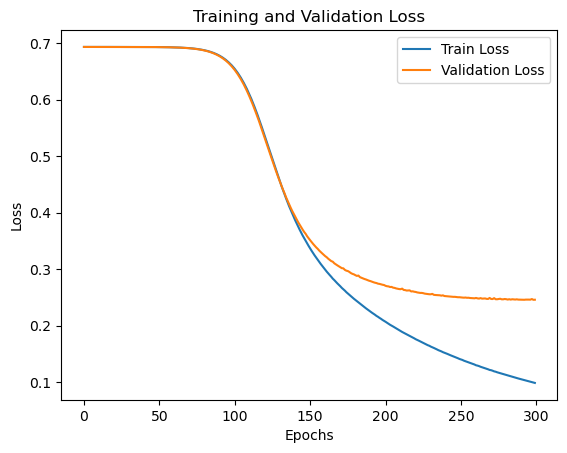

In [235]:
train_loss_plot(history)

In [236]:
'''Save the model weight biases, config and results for later use/comparison'''
import json
with open('baseline_tuned_history.json', 'w') as f:
    json.dump(history, f)

np.savez('baseline_tuned_model_weights.npz',
         weights_input_hidden=model.weights_input_hidden,
         bias_hidden=model.bias_hidden,
         weights_hidden_output=model.weights_hidden_output,
         bias_output=model.bias_output)

config = {
    'hidden_size': 8,
    'learning_rate': 0.01,
    'epochs': 300,
    'batch_size': 32,
    'min_df': 2,
    'input_size': int(x_train.shape[1])
}
with open('baseline_tuned_config.json', 'w') as f:
    json.dump(config, f)
